<font size="5">Here we import the Expansions.ipynb file in torder to have all of the definitions.</font>

In [1]:
%run /home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/wcdm_expansions.ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import matplotlib.patheffects as path_effects
from tqdm import tqdm
import awkward as ak
import pandas as pd
from scipy import integrate

In [3]:
min_z= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_z_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
min_y= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_y_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
min_log= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_log_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
min_pade= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_pade_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
success_ar = pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/success_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
true_ar = pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/true_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
chisq_ar = pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/fun_array_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')

# min_z= pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/min_z_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
# min_y= pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/min_y_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
# min_log= pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/min_log_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
# min_pade= pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/min_pade_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
# success_ar = pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/success_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
# true_ar = pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/true_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
# chisq_ar = pd.read_parquet('/home/jess/Cosmography/Colab/Parameter_estimation/1000_runs_zmax02to2/fun_array_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')

# Visualizing errors in dL with perfect parameters

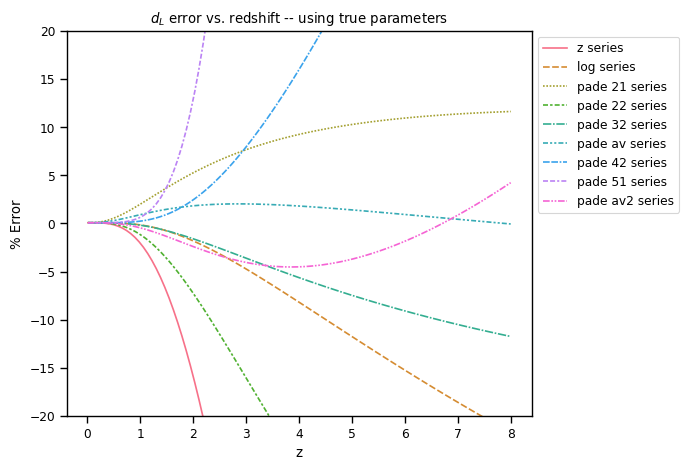

In [143]:
H0 = 70
Om = 0.3
Ok = 0
w = -1

zs = np.linspace(0.01, 8, 100)
my_cosmo = cosmo.wCDM(H0=H0, Om0=Om, Ode0=1.0-Om-Ok)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

H0p = to_cosmographic(H0, Om,Ok,w)[0]
q0p = to_cosmographic(H0, Om,Ok,w)[1]
j0p = to_cosmographic(H0, Om,Ok,w)[2]
s0p = to_cosmographic(H0, Om,Ok,w)[3]
c0p = to_cosmographic(H0, Om,Ok,w)[4]
p0p = to_cosmographic(H0, Om,Ok,w)[5]


ys = zs/(1+zs)
err_pade22 = 100*(dLpade22(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade21 = 100*(dLpade21(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade32 = 100*(dLpade32(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade42 = 100*(dLpade42(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade51 = 100*(dLpade51(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_z = 100*(z_series(zs, H0p, q0p, j0p, s0p,c0p, p0p, order = 4) - dls_true)/dls_true
err_y = 100*(y_series(ys, H0p, q0p, j0p, s0p,c0p, p0p, order = 4) - dls_true)/dls_true
err_log = 100*(log_series(np.log(1+zs), H0p, q0p, j0p, s0p, c0p,p0p,order= 6) - dls_true)/dls_true
err_padeaverage = 100*(dLpadeaverage(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_padeaverage2 = 100*(dLpadeaverage2(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 6) - dls_true)/dls_true


# Prepare the data in long form
data_p = pd.DataFrame({
    'zs': list(zs) * 9,
    'Difference': list(err_z) + list(err_log)+ list(err_pade21)+ list(err_pade22) + list(err_pade32) + list(err_padeaverage)+ list(err_pade42)+ list(err_pade51)+ list(err_padeaverage2),
    'Series': ['z series'] * len(zs) + ['log series'] * len(zs) + ['pade 21 series'] * len(zs)+ ['pade 22 series'] * len(zs)
     + ['pade 32 series'] * len(zs) + ['pade av series'] * len(zs)  + ['pade 42 series'] * len(zs) + ['pade 51 series'] * len(zs) + ['pade av2 series'] * len(zs) 
})


# Plot with hue and palette
plt.figure(figsize=(6, 5))
sns.lineplot(x='zs', y='Difference', hue='Series', style="Series", data=data_p, palette='husl')
plt.ylim(-20,20)
plt.xlabel('z')
plt.ylabel('% Error')
plt.title('$d_L$ error vs. redshift -- using true parameters')
# Positioning the legend outside of the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

In [151]:
# E1 = 1+ q0p
# E2 = -q0p**2 + j0p
# E3 = 3*q0p**2 + 3*q0p**3 - j0p*(4*q0p + 3)-s0p

H=H0
E1=q0p + 1
E2=(j0p - q0p**2)
E3=(-2*j0p*q0p/3 - j0p/2 + (q0p**3)/2 + (q0p**2)/2 - s0p/6)*6
E4=(+ c0p/24 - j0p**2/6 + 25*j0p*q0p**2/24 + 4*j0p*q0p/3 + j0p/2 - 5*q0p**4/8 - q0p**3 - q0p**2/2 + 7*q0p*s0p/24 + s0p/3) *24
E5=(- 11*c0p*q0p/120 - c0p/8 + 7*j0p**2*q0p/12 + j0p**2/2 - 7*j0p*q0p**3/4 \
    - 25*j0p*q0p**2/8 - 2*j0p*q0p + j0p*s0p/8 - j0p/2 - p0p/120 + 7*q0p**5/8 + 15*q0p**4/8 + 3*q0p**3/2 - q0p**2*s0p/2 + q0p**2/2 - 7*q0p*s0p/8 - s0p/2)*120

In [153]:
c=300000

err_eis2 = 100*(EIS(zs,H,E1,E2,order=2) - dls_true)/dls_true
err_eis3 = 100*(EIS(zs,H,E1,E2,E3, order=3) - dls_true)/dls_true
err_eis4 = 100*(EIS(zs,H,E1,E2,E3,E4,  order=3) - dls_true)/dls_true
err_eis5 = 100*(EIS(zs,H,E1,E2,E3,E4, E5, order=5) - dls_true)/dls_true

# lista =  list(err_z)+ list(err_log) +list(err_pade21)+ list(err_pade22) + list(err_pade32) + list(err_padeaverage)+ list(err_pade42)\
#         + list(err_pade51) +list(err_eis2) +list(err_eis3) + list(err_eis4) + list(err_eis5) 

# # Prepare the data in long form
# data_eis = pd.DataFrame({
#     'zs': list(zs) * 12,
#     'Difference': lista,
#     'Series':  ['z series'] * len(zs) +['log series'] * len(zs) + ['pade 21 series'] * len(zs)+ ['pade 22 series'] * len(zs)
#      + ['pade 32 series'] * len(zs) + ['pade av series'] * len(zs)  + ['pade 42 series'] * len(zs) + ['pade 51 series'] * len(zs)
#     +['EIS order 2'] * len(zs) +['EIS order 3'] * len(zs) + ['EIS order 4'] * len(zs) + ['EIS order 5'] * len(zs),
#     'Type': ['Taylor'] * len(zs) + ['Taylor'] * len(zs) + ['Pade'] *6 * len(zs) + ['Eis'] * 4*len(zs)
# })


# # Plot with hue and palette
# plt.figure(figsize=(8, 6))
# sns.set_context("talk")
# sns.lineplot(x='zs', y='Difference', hue='Series', style="Type", data=data_eis, palette='hls')
# #plt.axhline(y=0, ls=':', color = 'darkgrey')
# plt.ylim(-40,60)
# plt.xlabel('z')
# plt.ylabel('% Error')
# plt.title('$d_L$ error vs. redshift -- using true parameters')

# # Positioning the legend outside of the plot
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1.1))

# # Save the figure as a PNG, PDF, or JPEG
# #plt.savefig('dL_error_perfect_params_z12.png', dpi=500,  bbox_inches='tight')  # To save as PNG
# plt.show()

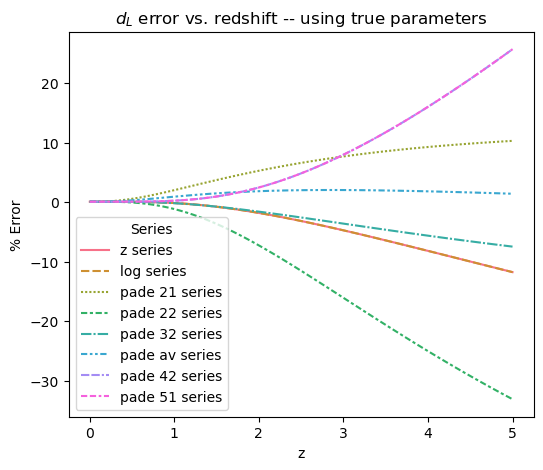

In [78]:
# Prepare the data in long form

lista = list(err_eis2) +list(err_eis3) + list(err_eis5) +list(err_log)+ list(err_padeaverage)


data_t = pd.DataFrame({
    'zs': list(zs) * 8,
    'Difference': list(err_log) + list(err_log)+ list(err_pade21)+ list(err_pade22) + list(err_pade32) + list(err_padeaverage)+ list(err_pade42)+ list(err_pade42),
    'Series': ['z series'] * len(zs) + ['log series'] * len(zs) + ['pade 21 series'] * len(zs)+ ['pade 22 series'] * len(zs)
     + ['pade 32 series'] * len(zs) + ['pade av series'] * len(zs)  + ['pade 42 series'] * len(zs) + ['pade 51 series'] * len(zs)
})


# Plot with hue and palette
plt.figure(figsize=(6, 5))
sns.lineplot(x='zs', y='Difference', hue='Series', style="Series", data=data_t, palette='husl')
#plt.ylim(-50,50)
plt.xlabel('z')
plt.ylabel('% Error')
plt.title('$d_L$ error vs. redshift -- using true parameters')

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

# Creating par_est arrays

In [7]:
# Creating par_est arrays for each order
N_runs = 1000
N_z = 10

N_fun = 4 
H0_est_2 = np.zeros((N_z, N_fun, N_runs))
q0_est_2 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_2[i, :, j] = ([true_ar.iloc[0,0][i][j][0], min_z.iloc[0,0][i][j][0],min_log.iloc[0,0][i][j][0],min_y.iloc[0,0][i][j][0]])
        q0_est_2[i, :, j] = ([true_ar.iloc[0,0][i][j][1], min_z.iloc[0,0][i][j][1],min_log.iloc[0,0][i][j][1],min_y.iloc[0,0][i][j][1]])
        #notnan = ~np.isnan(H0_est_2[o][z])


N_fun = 5 
H0_est_3 = np.zeros((N_z, N_fun, N_runs))
q0_est_3 = np.zeros((N_z, N_fun, N_runs))
j0_est_3 = np.zeros((N_z, N_fun, N_runs))
s0_est_3 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_3[i, :, j] = ([true_ar.iloc[1,0][i][j][0], min_z.iloc[1,0][i][j][0],min_log.iloc[1,0][i][j][0],min_y.iloc[1,0][i][j][0],min_pade.iloc[1,0][i][0][j][0]])
        q0_est_3[i, :, j] = ([true_ar.iloc[1,0][i][j][1], min_z.iloc[1,0][i][j][1],min_log.iloc[1,0][i][j][1],min_y.iloc[1,0][i][j][1],min_pade.iloc[1,0][i][0][j][1]])
        j0_est_3[i, :, j] = ([true_ar.iloc[1,0][i][j][2], min_z.iloc[1,0][i][j][2],min_log.iloc[1,0][i][j][2],min_y.iloc[1,0][i][j][2],min_pade.iloc[1,0][i][0][j][2]])


N_fun = 6
H0_est_4 = np.zeros((N_z, N_fun, N_runs))
q0_est_4 = np.zeros((N_z, N_fun, N_runs))
j0_est_4 = np.zeros((N_z, N_fun, N_runs))
s0_est_4 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][0], min_z.iloc[2,0][i][j][0],min_log.iloc[2,0][i][j][0],min_y.iloc[2,0][i][j][0],min_pade.iloc[2,0][i][0][j][0],min_pade.iloc[2,0][i][1][j][0]])
        q0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][1], min_z.iloc[2,0][i][j][1],min_log.iloc[2,0][i][j][1],min_y.iloc[2,0][i][j][1],min_pade.iloc[2,0][i][0][j][1],min_pade.iloc[2,0][i][1][j][1]])
        j0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][2], min_z.iloc[2,0][i][j][2],min_log.iloc[2,0][i][j][2],min_y.iloc[2,0][i][j][2],min_pade.iloc[2,0][i][0][j][2],min_pade.iloc[2,0][i][1][j][2]])
        s0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][3], min_z.iloc[2,0][i][j][3],min_log.iloc[2,0][i][j][3],min_y.iloc[2,0][i][j][3],min_pade.iloc[2,0][i][0][j][3],min_pade.iloc[2,0][i][1][j][3]])

N_fun = 7 
H0_est_5 = np.zeros((N_z, N_fun, N_runs))
q0_est_5 = np.zeros((N_z, N_fun, N_runs))
j0_est_5 = np.zeros((N_z, N_fun, N_runs))
s0_est_5 = np.zeros((N_z, N_fun, N_runs))
c0_est_5 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][0], min_z.iloc[3,0][i][j][0],min_log.iloc[3,0][i][j][0],min_y.iloc[3,0][i][j][0],min_pade.iloc[3,0][i][0][j][0],min_pade.iloc[3,0][i][1][j][0], min_pade.iloc[3,0][i][2][j][0]])
        q0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][1], min_z.iloc[3,0][i][j][1],min_log.iloc[3,0][i][j][1],min_y.iloc[3,0][i][j][1],min_pade.iloc[3,0][i][0][j][1],min_pade.iloc[3,0][i][1][j][1], min_pade.iloc[3,0][i][2][j][1]])
        j0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][2], min_z.iloc[3,0][i][j][2],min_log.iloc[3,0][i][j][2],min_y.iloc[3,0][i][j][2],min_pade.iloc[3,0][i][0][j][2],min_pade.iloc[3,0][i][1][j][2], min_pade.iloc[3,0][i][2][j][2]])
        s0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][3], min_z.iloc[3,0][i][j][3],min_log.iloc[3,0][i][j][3],min_y.iloc[3,0][i][j][3],min_pade.iloc[3,0][i][0][j][3],min_pade.iloc[3,0][i][1][j][3], min_pade.iloc[3,0][i][2][j][3]])
        c0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][4], min_z.iloc[3,0][i][j][4],min_log.iloc[3,0][i][j][4],min_y.iloc[3,0][i][j][4],min_pade.iloc[3,0][i][0][j][4],min_pade.iloc[3,0][i][1][j][4], min_pade.iloc[3,0][i][2][j][4]])

H0_est_all = (H0_est_2, H0_est_3, H0_est_4, H0_est_5)
q0_est_all = (q0_est_2, q0_est_3, q0_est_4, q0_est_5)
# j0_est_all = (np.full(len(H0_est_2),np.nan), j0_est_3, j0_est_4, j0_est_5)
# s0_est_all = (np.full(len(H0_est_2),np.nan), np.full(len(H0_est_3),np.nan), s0_est_4, s0_est_5)
# c0_est_all = (np.full(len(H0_est_2),np.nan), np.full(len(H0_est_3),np.nan), np.full(len(H0_est_4),np.nan), s0_est_5)

In [8]:
H0_est_all = (H0_est_2, H0_est_3, H0_est_4, H0_est_5)
q0_est_all = (q0_est_2, q0_est_3, q0_est_4, q0_est_5)
j0_est_all = (np.full(len(H0_est_2),np.nan), j0_est_3, j0_est_4, j0_est_5)
s0_est_all = (np.full(len(H0_est_2),np.nan), np.full(len(H0_est_3),np.nan), s0_est_4, s0_est_5)
H0_list = []
q0_list = []
j0_list = []
s0_list = []

# H0_all_est_med = ((fun, z, order))
H0_all_est_med = np.full((7, 10, 4), np.nan)
q0_all_est_med = np.full((7, 10, 4), np.nan)
j0_all_est_med = np.full((7, 10, 4), np.nan)
s0_all_est_med = np.full((7, 10, 4), np.nan)


for o in range(4):
    for z in range(N_z):
        for f in range(len(H0_est_all[o][0])):
            notnan = ~np.isnan(H0_est_all[o][z][f]) # Here I'm saving the z in the opposite order so matrix plot will be in the right way
            H0_est_clean = H0_est_all[o][z][f][notnan]
            q0_est_clean = q0_est_all[o][z][f][notnan]
            H0_all_est_med[f][z][o] = np.median(H0_est_clean)
            q0_all_est_med[f][z][o] = np.median(q0_est_clean)
            H0_list.append(np.median(H0_est_clean))
            q0_list.append(np.median(q0_est_clean))


for o in range(3):
    for z in range(N_z):
        for f in range(len(j0_est_all[o+1][0])):
            notnan = ~np.isnan(j0_est_all[o+1][z][f])
            j0_est_clean = j0_est_all[o+1][z][f][notnan]
            j0_all_est_med[f][z][o+1] = np.median(j0_est_clean)
            j0_list.append(np.median(j0_est_clean))

for o in range(2):
    for z in range(N_z):
        for f in range(len(s0_est_all[o+2][0])):
            notnan = ~np.isnan(s0_est_all[o+2][z][f])
            s0_est_clean = s0_est_all[o+2][z][f][notnan]
            s0_all_est_med[f][z][o+2] = np.median(s0_est_clean)
            s0_list.append(np.median(s0_est_clean))

# Calculating errors in dL

In [9]:
def to_cosmology(q0, j0=1, k=0, W=-1):
    if W == -1:
        if k == 0:
            Om = 2/3 * (q0 + 1)
            return Om
        else:
            Om = 2/3 * (q0 + j0)
            Ok = 1 - j0
            return Om, Ok
    else:
        Om = (2*(j0 - q0 - 2*q0**2))/(1 + 2*j0 - 6*q0)
        Ok = 0
        w = (-1 - 2*j0 + 6*q0)/(3 - 6*q0)        
        return Om, Ok, w

In [10]:
# Forth order

n = 1000
N = 10
z_max_array = np.linspace(0.2, 2, N)

H0_true = np.full((10,1,1000), np.nan)
q0_true = np.full((10,1,1000), np.nan)
j0_true = np.full((10,1,1000), np.nan)
s0_true = np.full((10,1,1000), np.nan)


diff_z_av = np.zeros(N)
diff_log_av = np.zeros(N)
diff_y_av = np.zeros(N)
diff_pade21_av = np.zeros(N)
diff_pade22_av = np.zeros(N)


for z in range(N):

    H0_true[z][0] = H0_est_4[z, 0,:]
    q0_true[z][0] = q0_est_4[z, 0,:]
    j0_true[z][0] = j0_est_4[z, 0,:]
    s0_true[z][0] = s0_est_4[z, 0,:]

    
    Om_true = to_cosmology(q0_est_4[z][0])
    Ok_true = 0
    w_true = -1

    zs_temp = z_max_array[z]
    log1zs_temp = np.log(1+zs_temp)

    diff_z = []
    diff_y = []
    diff_log = []
    diff_pade21 = []
    diff_pade22 = []
    for s in range(n):
        my_cosmo = cosmo.wCDM(H0=H0_true[z][0][s], Om0=Om_true[s], Ode0=1.0-Om_true[s], w0=w_true)
        dls_true = my_cosmo.luminosity_distance(zs_temp).to(u.Mpc).value

        H0_est_clean = []
        q0_est_clean = []
        j0_est_clean = []
        s0_est_clean = []
        for f in range(5):
            notnan = ~np.isnan(H0_est_4[z, f+1, :])
            H0_est_clean.append(H0_est_4[z][f+1][notnan])
            q0_est_clean.append(q0_est_4[z][f+1][notnan])
            j0_est_clean.append(j0_est_4[z][f+1][notnan])
            s0_est_clean.append(s0_est_4[z][f+1][notnan])

        
        my_z = z_series(zs_temp, H0_est_clean[0], q0_est_clean[0], j0 = j0_est_clean[0], s0 = s0_est_clean[0], order = 4)
        diff_z.append(100*(abs(my_z - dls_true) / dls_true))

        log1zs = np.log(1 + zs_temp)
        my_log = log_series(log1zs, H0_est_clean[1], q0_est_clean[1], j0 = j0_est_clean[1], s0 = s0_est_clean[1], order = 4)
        diff_log.append(100*(abs(my_log - dls_true) / dls_true))

        ys = zs_temp/(1+zs_temp)
        my_y = y_series(ys, H0_est_clean[2], q0_est_clean[2], j0 = j0_est_clean[2], s0 = s0_est_clean[2], order = 4)
        diff_y.append(100*(abs(my_y - dls_true) / dls_true))

        my_pade21 = dLpade21(zs_temp, H0_est_clean[3], q0_est_clean[3], j0 = j0_est_clean[3])
        diff_pade21.append(100*(abs(my_pade21 - dls_true) / dls_true))

        my_pade22 = dLpade22(zs_temp, H0_est_clean[4], q0_est_clean[4], j0 = j0_est_clean[4], s0 = s0_est_clean[4])
        diff_pade22.append(100*(abs(my_pade22 - dls_true) / dls_true))

    diff_z_av[z] = np.median(diff_z)
    diff_y_av[z] = np.median(diff_y)
    diff_log_av[z] = np.median(diff_log)
    diff_pade21_av[z] = np.median(diff_pade21)
    diff_pade22_av[z] = np.median(diff_pade22)

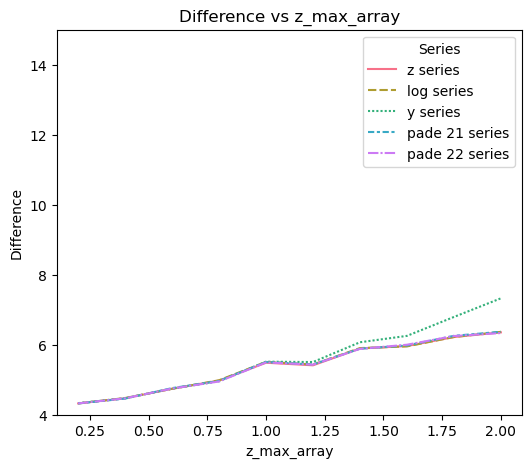

In [11]:
# Prepare the data in long form
data = pd.DataFrame({
    'z_max_array': list(z_max_array) * 5,
    'Difference': list(diff_z_av) + list(diff_log_av)+ list(diff_y_av) + list(diff_pade21_av)+ list(diff_pade22_av),
    'Series': ['z series'] * len(z_max_array) + ['log series'] * len(z_max_array) + ['y series'] * len(z_max_array) + ['pade 21 series'] * len(z_max_array)+ ['pade 22 series'] * len(z_max_array)
})

# Plot with hue and palette
plt.figure(figsize=(6,5))
sns.lineplot(x='z_max_array', y='Difference', hue='Series', style = 'Series', data=data, palette='husl')

plt.xlabel('z_max_array')
plt.ylabel('Difference')
plt.ylim(4, 15)
plt.title('Difference vs z_max_array')

#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')
plt.show()


In [12]:
# Fifth order

n = 1000
N = 10
z_max_array = np.linspace(0.2, 2, N)

H0_true = np.full((10,1,1000), np.nan)
q0_true = np.full((10,1,1000), np.nan)
j0_true = np.full((10,1,1000), np.nan)
s0_true = np.full((10,1,1000), np.nan)
c0_true = np.full((10,1,1000), np.nan)


diff_z_av = np.zeros(N)
diff_log_av = np.zeros(N)
diff_y_av = np.zeros(N)
diff_pade21_av = np.zeros(N)
diff_pade22_av = np.zeros(N)
diff_pade32_av = np.zeros(N)
# diff_pade42_av = np.zeros(N)
# diff_pade51_av = np.zeros(N)


for z in range(N):

    H0_true[z][0] = H0_est_5[z, 0,:]
    q0_true[z][0] = q0_est_5[z, 0,:]
    j0_true[z][0] = j0_est_5[z, 0,:]
    s0_true[z][0] = s0_est_5[z, 0,:]
    c0_true[z][0] = c0_est_5[z, 0,:]

    Om_true = to_cosmology(q0_est_5[z][0])
    Ok_true = 0
    w_true = -1

    zs_temp = z_max_array[z]
    log1zs_temp = np.log(1+zs_temp)

    diff_z = []
    diff_y = []
    diff_log = []
    diff_pade21 = []
    diff_pade22 = []
    diff_pade32 = []
    for s in range(n):
        my_cosmo = cosmo.wCDM(H0=H0_true[z][0][s], Om0=Om_true[s], Ode0=1.0-Om_true[s], w0=w_true)
        dls_true = my_cosmo.luminosity_distance(zs_temp).to(u.Mpc).value

        H0_est_clean = []
        q0_est_clean = []
        j0_est_clean = []
        s0_est_clean = []
        c0_est_clean = []
        for f in range(6):
            notnan = ~np.isnan(H0_est_5[z, f+1, :])
            H0_est_clean.append(H0_est_5[z][f+1][notnan])
            q0_est_clean.append(q0_est_5[z][f+1][notnan])
            j0_est_clean.append(j0_est_5[z][f+1][notnan])
            s0_est_clean.append(s0_est_5[z][f+1][notnan])
            c0_est_clean.append(c0_est_5[z][f+1][notnan])

        
        my_z = z_series(zs_temp, H0_est_clean[0], q0_est_clean[0], j0 = j0_est_clean[0], s0 = s0_est_clean[0], c0 = c0_est_clean[0], order = 5)
        diff_z.append(100*(abs(my_z - dls_true) / dls_true))

        log1zs = np.log(1 + zs_temp)
        my_log = log_series(log1zs, H0_est_clean[1], q0_est_clean[1], j0 = j0_est_clean[1], s0 = s0_est_clean[1], c0 = c0_est_clean[1], order = 5)
        diff_log.append(100*(abs(my_log - dls_true) / dls_true))

        ys = zs_temp/(1+zs_temp)
        my_y = y_series(ys, H0_est_clean[2], q0_est_clean[2], j0 = j0_est_clean[2], s0 = s0_est_clean[2], c0 = c0_est_clean[2], order = 5)
        diff_y.append(100*(abs(my_y - dls_true) / dls_true))

        my_pade21 = dLpade21(zs_temp, H0_est_clean[3], q0_est_clean[3], j0 = j0_est_clean[3])
        diff_pade21.append(100*(abs(my_pade21 - dls_true) / dls_true))

        my_pade22 = dLpade22(zs_temp, H0_est_clean[4], q0_est_clean[4], j0 = j0_est_clean[4], s0 = s0_est_clean[4])
        diff_pade22.append(100*(abs(my_pade22 - dls_true) / dls_true))

        my_pade32 = dLpade32(zs_temp, H0_est_clean[5], q0_est_clean[5], j0 = j0_est_clean[5], s0 = s0_est_clean[5], c0 = c0_est_clean[5])
        diff_pade32.append(100*(abs(my_pade32 - dls_true) / dls_true))

    diff_z_av[z] = np.median(diff_z)
    diff_y_av[z] = np.median(diff_y)
    diff_log_av[z] = np.median(diff_log)
    diff_pade21_av[z] = np.median(diff_pade21)
    diff_pade22_av[z] = np.median(diff_pade22)
    diff_pade32_av[z] = np.median(diff_pade32)

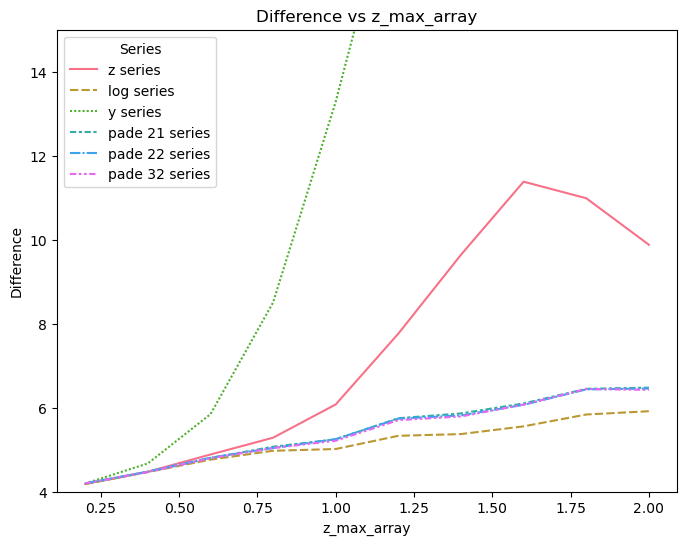

In [13]:
# Prepare the data in long form
data = pd.DataFrame({
    'z_max_array': list(z_max_array) * 6,
    'Difference': list(diff_z_av) + list(diff_log_av)+ list(diff_y_av) + list(diff_pade21_av)+ list(diff_pade22_av)+ list(diff_pade32_av),
    'Series': ['z series'] * len(z_max_array) + ['log series'] * len(z_max_array) + ['y series'] * len(z_max_array) + ['pade 21 series'] * len(z_max_array)+ ['pade 22 series'] * len(z_max_array)
    + ['pade 32 series'] * len(z_max_array)
})

# Plot with hue and palette
plt.figure(figsize=(8, 6))
sns.lineplot(x='z_max_array', y='Difference', hue='Series', style = 'Series', data=data, palette='husl')

plt.xlabel('z_max_array')
plt.ylabel('Difference')
plt.ylim(4, 15)
plt.title('Difference vs z_max_array')
plt.show()


# Plot of the expansions for their best-fit parameters (regardless how bad they might be) vs. the plot with the true cosmology values

In [14]:
Om

0.41

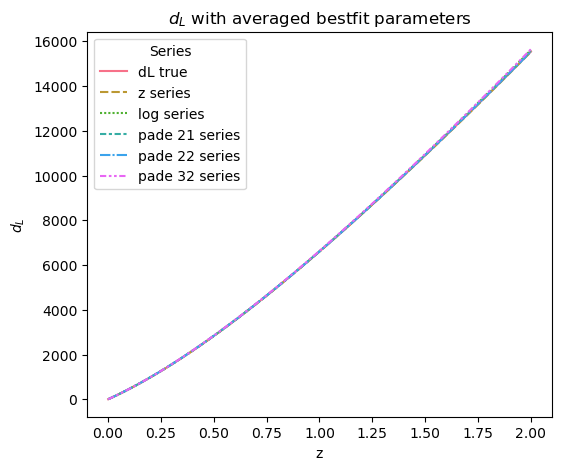

In [15]:
# H0_all_est_med = ((fun, z, order))

Om = to_cosmology(q0_all_est_med[0][9][2])
Ok = 0
zs = np.linspace(0.001, 2, 100)
my_cosmo = cosmo.wCDM(H0=H0_all_est_med[0][9][2], Om0=Om, Ode0=1.0-Om-Ok)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value
z=9
ys = zs/(1+zs)


dL_true = dls_true
dL_z = z_series(zs, H0_all_est_med[1][z][2], q0_all_est_med[1][z][2], j0 =  j0_all_est_med[1][z][2], s0 =  s0_all_est_med[1][z][2], order = 4)
dL_log = log_series(np.log(1+zs), H0_all_est_med[2][z][2], q0_all_est_med[2][z][2], j0 =  j0_all_est_med[2][z][2], s0 =  s0_all_est_med[2][z][2], order = 4)
dL_y = y_series(ys, H0_all_est_med[3][z][2], q0_all_est_med[3][z][2], j0 =  j0_all_est_med[3][z][2], s0 =  s0_all_est_med[3][z][2], order = 4)
dL_pade21 = dLpade21(zs, H0_all_est_med[4][z][2], q0_all_est_med[4][z][2], j0 =  j0_all_est_med[4][z][2], s0 =  s0_all_est_med[4][z][2])
dL_pade22 = dLpade22(zs, H0_all_est_med[5][z][2], q0_all_est_med[5][z][2], j0 =  j0_all_est_med[5][z][2], s0 =  s0_all_est_med[5][z][2])
dL_pade32 = dLpade32(zs, H0_all_est_med[6][z][3], q0_all_est_med[6][z][3], j0 =  j0_all_est_med[6][z][3], s0 =  s0_all_est_med[6][z][3])
#dL_pade42 = dLpade42(zs, H0_all_est_med[7][z][3], q0_all_est_med[7][z][3], j0 =  j0_all_est_med[7][z][3], s0 =  s0_all_est_med[7][z][3], order = 4)


# dL_z = 100*abs(tdL_z - tdL_true)/tdL_true
# dL_log = 100*abs(tdL_log - tdL_true)/tdL_true
# dL_y = 100*abs(tdL_y - tdL_true)/tdL_true
# dL_pade21 = 100*abs(tdL_pade21 - tdL_true)/tdL_true
# dL_pade22 = 100*abs(tdL_pade22 - tdL_true)/tdL_true
# dL_pade32 = 100*abs(tdL_pade32 - tdL_true)/tdL_true

# Prepare the data in long form
data_av_fit = pd.DataFrame({
	'zs': list(zs) * 6,
	'Difference': list(dL_true) + list(dL_z) + list(dL_log)+ list(dL_pade21)+ list(dL_pade22) + list(dL_pade32),
	'Series': ['dL true'] * len(zs) + ['z series'] * len(zs) + ['log series'] * len(zs) + ['pade 21 series'] * len(zs)+ ['pade 22 series'] * len(zs)
	+ ['pade 32 series'] * len(zs) 
})


# Plot with hue and palette
plt.figure(figsize=(6, 5))
sns.lineplot(x='zs', y='Difference', hue='Series', style="Series", data=data_av_fit, palette='husl')
#plt.ylim(0,50)
plt.xlabel('z')
plt.ylabel('$d_L$')
plt.title('$d_L$ with averaged bestfit parameters')

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()


In [31]:
    # Eis series
H0_true, E1_true, E2_true, E3_true, E4_true, E5_true = to_statefinders([H0_true, q0_true, j0_true, s0_true, c0_true, p0_true])
H0_true, E1_true, E2_true, E3_true, E4_true, E5_true 

(67.69032659722642,
 -0.7116280273839475,
 1.5064144493583684,
 3.0720067430195708,
 11.770334125692841,
 42.05824020632454)

In [32]:
E0_true = 1
E1_true = 1+ q0_true
E2_true = -q0_true**2 + j0_true
E3_true = 3*q0_true**2 + 3*q0_true**3 - j0_true*(4*q0_true + 3)-s0_true
H0_true, E1_true, E2_true, E3_true, E4_true, E5_true 

(67.69032659722642,
 1.2883719726160525,
 0.9168416054095267,
 -0.9669551379817167,
 11.770334125692841,
 42.05824020632454)

<font size='5'>**Percentage error calculation in d_L assuming the same cosmographic parameters**</font>

<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:64: SyntaxWarning: invalid escape sequence '\O'
<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:64: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_22941/2819282162.py:62: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$\Omega_{m}$', fontsize=14)
/tmp/ipykernel_22941/2819282162.py:64: SyntaxWarning: invalid escape sequence '\O'
  plt.title('Percentage Difference between $d_{Log}$ and $d_{true}$ vs. $\Omega_{m}$', fontsize=0.1)
  0%|                                                   | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_22941/2819282162.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_eistrue[i] = 100*(abs(my_eis - dls_true) / dls_true)
100%|███████████████████████████████████████| 200/200 [00:00<00:00, 1445.81it/s]


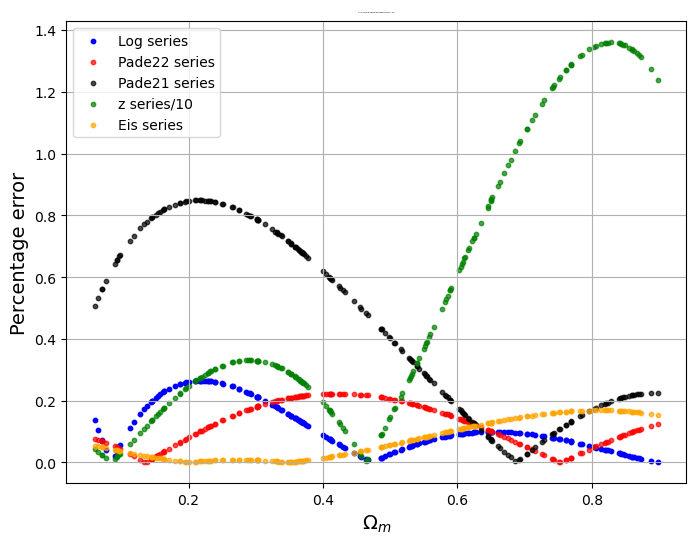

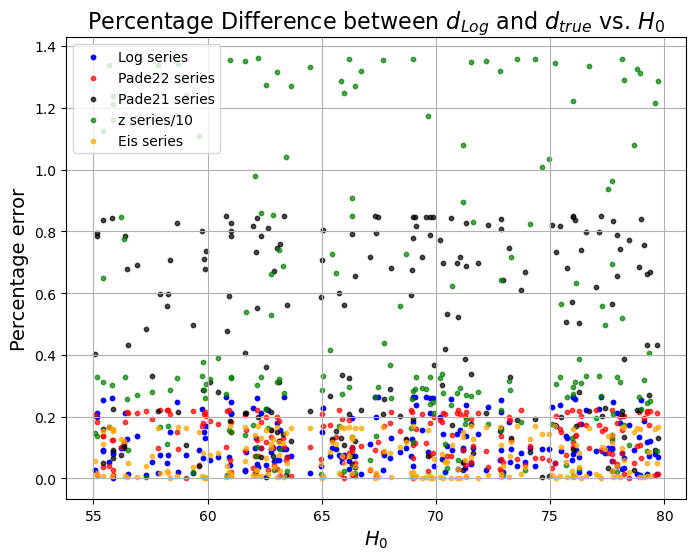

In [98]:
n = 200

dtheta_log = np.zeros((n,4))
diff_logtrue = np.zeros(n)
diff_pade22true = np.zeros(n)
diff_pade21true = np.zeros(n)
diff_ztrue = np.zeros(n)
diff_eistrue = np.zeros(n)
H0_rec = np.zeros(n)
Om_rec = np.zeros(n)

# n=100 interations estimating the values for H0, Om etc
for i in tqdm(range(n)):

    H0_true = np.random.uniform(55, 80)
    Om_true = np.random.uniform(0.05, 0.9)
    Ok_true = 0
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs_temp = 0.6
    log1zs_temp = np.log(1+zs_temp)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs_temp).to(u.Mpc).value

    
    my_log = log_series(log1zs_temp, H0_true, q0_true, j0_true, s0_true, order = 4)
    my_Pade22 = dLpade22(zs_temp, H0_true, q0_true, j0_true, s0_true)
    my_Pade21 = dLpade21(zs_temp, H0_true, q0_true, j0_true)
    my_z = z_series(zs_temp, H0_true, q0_true, j0_true, s0_true, order = 4)

    # Eis series
    E0_true = 1
    E1_true = 1+ q0_true
    E2_true = -q0_true**2 + j0_true
    E3_true = 3*q0_true**2 + 3*q0_true**3 - j0_true*(4*q0_true + 3)-s0_true
    zs_temp = np.array([zs_temp])
    
    my_eis = EIS(zs_temp, H0=H0_true, E1=E1_true, E2=E2_true, E3 = E3_true, order = 3)

    # # Eis series
    # H0_true, E1_true, E2_true, E3_true, E4_true, E5_true = to_statefinders([H0_true, q0_true, j0_true, s0_true, c0_true, p0_true])
    # zs_temp = np.array([zs_temp])
    # my_eis = EIS(zs_temp, H0=H0_true, E1=E1_true, E2=E2_true, E3 = E3_true, E4 = E4_true, order = 4)

    H0_rec[i] = H0_true
    Om_rec[i] = Om_true
    diff_logtrue[i] = 100*(abs(my_log - dls_true) / dls_true)
    diff_pade22true[i] = 100*(abs(my_Pade22 - dls_true) / dls_true)
    diff_pade21true[i] = 100*(abs(my_Pade21 - dls_true) / dls_true)
    diff_ztrue[i] = 100*(abs(my_z - dls_true) / dls_true)
    diff_eistrue[i] = 100*(abs(my_eis - dls_true) / dls_true)

# Plot diff_logtrue vs Om_rec
plt.figure(figsize=(8, 6))
plt.scatter(Om_rec, diff_logtrue, color='blue', alpha=1, label='Log series', s=10)
plt.scatter(Om_rec, diff_pade22true, color='red', alpha=0.7, label='Pade22 series', s=10)
plt.scatter(Om_rec, diff_pade21true, color='black', alpha=0.7, label='Pade21 series', s=10)
plt.scatter(Om_rec, diff_ztrue, color='green', alpha=0.7, label='z series/10', s=10)
plt.scatter(Om_rec, diff_eistrue, color='orange', alpha=0.7, label='Eis series', s=10)
plt.legend()
plt.xlabel('$\Omega_{m}$', fontsize=14)
plt.ylabel('Percentage error', fontsize=14)
plt.title('Percentage Difference between $d_{Log}$ and $d_{true}$ vs. $\Omega_{m}$', fontsize=0.1)
plt.grid(True)
plt.show()

# Plot diff_logtrue vs H0
plt.figure(figsize=(8, 6))
plt.scatter(H0_rec, diff_logtrue, color='blue', alpha=1, label='Log series', s=10)
plt.scatter(H0_rec, diff_pade22true, color='red', alpha=0.7, label='Pade22 series', s=10)
plt.scatter(H0_rec, diff_pade21true, color='black', alpha=0.7, label='Pade21 series', s=10)
plt.scatter(H0_rec, diff_ztrue, color='green', alpha=0.7, label='z series/10', s=10)
plt.scatter(H0_rec, diff_eistrue, color='orange', alpha=0.7, label='Eis series', s=10)
plt.legend()
plt.xlabel('$H_{0}$', fontsize=14)
plt.ylabel('Percentage error', fontsize=14)
plt.title('Percentage Difference between $d_{Log}$ and $d_{true}$ vs. $H_{0}$', fontsize=16)
plt.grid(True)
plt.show()

In [66]:
err_log[4]

array([-99.97051463, -98.42516313, -96.77339742, -95.02156991,
       -93.17581209, -91.24200067, -89.22573607, -87.13233096,
       -84.96680671, -82.73389553, -80.43804703, -78.08343757,
       -75.67398165, -73.2133445 , -70.70495522, -68.15202021,
       -65.55753644, -62.92430448, -60.25494105, -57.551891  ,
       -54.8174387 , -52.05371888, -49.26272671, -46.44632732,
       -43.60626471, -40.74417002, -37.86156931, -34.95989069,
       -32.04047106, -29.10456234, -26.15333718, -23.1878944 ,
       -20.20926388, -17.21841126, -14.21624218, -11.20360625,
        -8.18130078,  -5.15007417,  -2.11062913,   0.93637438,
         3.99031641,   7.05061444,  10.11672099,  13.18812145,
        16.264332  ,  19.34489766,  22.42939054,  25.51740817,
        28.60857192,  31.70252557,  34.79893395,  37.89748167,
        40.99787197,  44.09982554,  47.20307959,  50.30738679,
        53.41251442,  56.5182435 ,  59.62436801,  62.73069414,
        65.83703959,  68.94323289,  72.04911286,  75.15

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 437.18it/s]


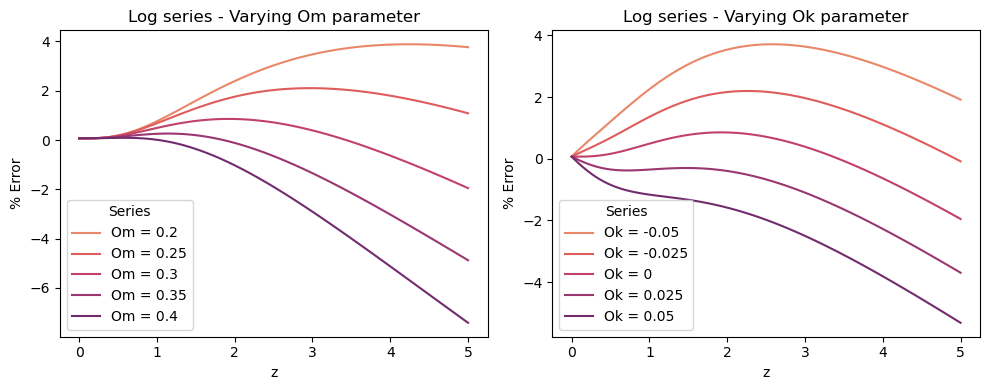

In [5]:
err_log = []
Om = [0.2, 0.25, 0.3, 0.35, 0.4]
n = len(Om)

for i in tqdm(range(n)):

    H0_true = 73
    Om_true = Om[i]
    Ok_true = 0
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(log_series(np.log(1+zs), H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= 4) - dls_true)/dls_true)


# Prepare the data in long form
data_Om = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Om = 0.2'] * len(zs) + ['Om = 0.25'] * len(zs) + ['Om = 0.3'] * len(zs) + ['Om = 0.35'] * len(zs)
     + ['Om = 0.4'] * len(zs)
})

err_log = []
Ok = [-0.05, -0.025, 0, 0.025, 0.05]
n = len(Om)

for i in tqdm(range(n)):

    H0_true = 73
    Om_true = 0.3 #Om[i]
    Ok_true = Ok[i]
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(log_series(np.log(1+zs), H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= 4) - dls_true)/dls_true)

# Prepare the data in long form
data_Ok = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Ok = -0.05'] * len(zs) + ['Ok = -0.025'] * len(zs) + ['Ok = 0'] * len(zs) + ['Ok = 0.025'] * len(zs)
     + ['Ok = 0.05'] * len(zs)
})

# Create a figure with two subplots side by side (ncols=2)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Om, palette='flare', ax = axes[0])
axes[0].set_xlabel('z')
axes[0].set_ylabel('% Error')
axes[0].set_title('Log series - Varying Om parameter')

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Ok, palette='flare', ax = axes[1])
axes[1].set_xlabel('z')
axes[1].set_ylabel('% Error')
axes[1].set_title('Log series - Varying Ok parameter')

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 696.91it/s]


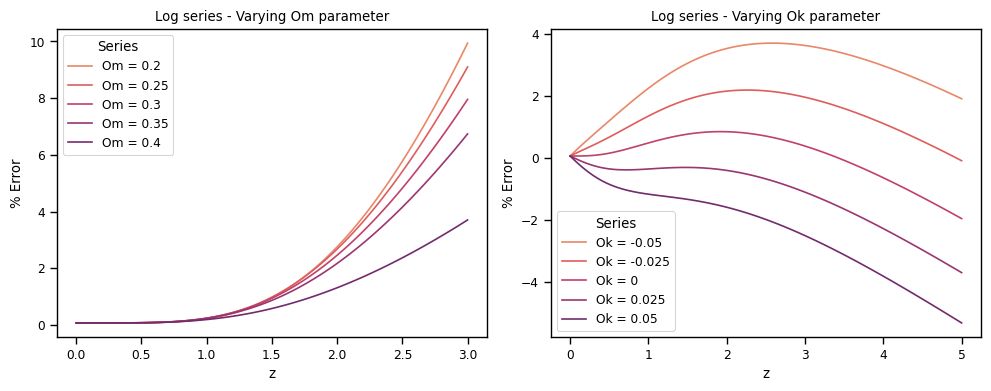

In [150]:
err_log = []
Om = [0.2, 0.25, 0.3, 0.35, 0.5]
n = len(Om)
orderr = 4
for i in tqdm(range(n)):

    H0_true = 73
    Om_true = Om[i]
    Ok_true = 0
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 3, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(dLpade42(zs, H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= orderr) - dls_true)/dls_true)


# Prepare the data in long form
data_Om = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Om = 0.2'] * len(zs) + ['Om = 0.25'] * len(zs) + ['Om = 0.3'] * len(zs) + ['Om = 0.35'] * len(zs)
     + ['Om = 0.4'] * len(zs)
})

err_log = []
Ok = [-0.05, -0.025, 0, 0.025, 0.05]
n = len(Om)

for i in tqdm(range(n)):

    H0_true = 73
    Om_true = 0.3 #Om[i]
    Ok_true = Ok[i]
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(log_series(np.log(1+zs), H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= orderr) - dls_true)/dls_true)

# Prepare the data in long form
data_Ok = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Ok = -0.05'] * len(zs) + ['Ok = -0.025'] * len(zs) + ['Ok = 0'] * len(zs) + ['Ok = 0.025'] * len(zs)
     + ['Ok = 0.05'] * len(zs)
})

# Create a figure with two subplots side by side (ncols=2)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))
sns.set_context("paper")
# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Om, palette='flare', ax = axes[0])
axes[0].set_xlabel('z')
axes[0].set_ylabel('% Error')
axes[0].set_title('Log series - Varying Om parameter')

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Ok, palette='flare', ax = axes[1])
axes[1].set_xlabel('z')
axes[1].set_ylabel('% Error')
axes[1].set_title('Log series - Varying Ok parameter')

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 316.35it/s]


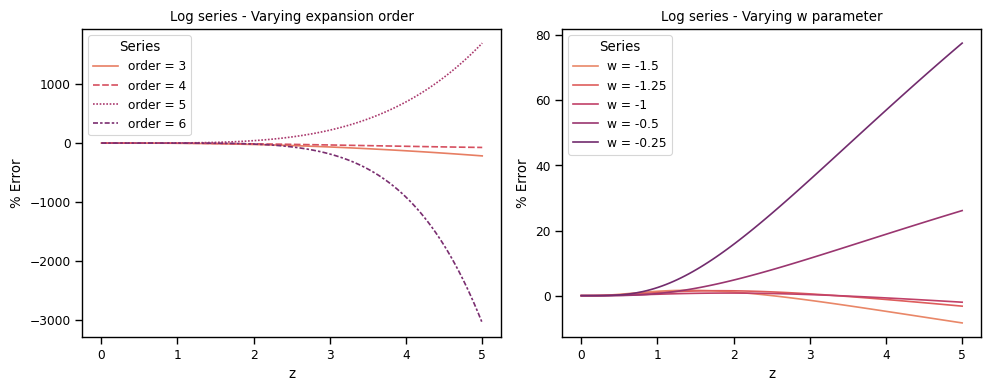

In [148]:
err_log = []
orderr = [3, 4, 5, 6]
n = len(orderr)
sns.set_context("paper")
for i in tqdm(range(n)):

    H0_true = 73
    Om_true = 0.33
    Ok_true = 0
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(dLpade42(zs, H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= orderr[i]) - dls_true)/dls_true)
    #log_series(np.log(1+zs)

# Prepare the data in long form
data_order = pd.DataFrame({
    'zs': list(zs) * n,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]),
    'Series': ['order = 3'] * len(zs) + ['order = 4'] * len(zs) + ['order = 5'] * len(zs) + ['order = 6'] * len(zs)
})

err_log = []
w = [-1.5, -1.25, -1, 1.25, 1.5]
n = len(w)

for i in tqdm(range(n)):

    H0_true = 73
    Om_true = 0.3 #Om[i]
    Ok_true = 0
    w_true = w[i]
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(log_series(np.log(1+zs), H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= 4) - dls_true)/dls_true)

# Prepare the data in long form
data_w = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['w = -1.5'] * len(zs) + ['w = -1.25'] * len(zs) + ['w = -1']* len(zs) + ['w = -0.5'] * len(zs)
     + ['w = -0.25'] * len(zs)
})

# Create a figure with two subplots side by side (ncols=2)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series', style = 'Series',  data=data_order, palette='flare', ax = axes[0])
axes[0].set_xlabel('z')
axes[0].set_ylabel('% Error')
axes[0].set_title('Log series - Varying expansion order')

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_w, palette='flare', ax = axes[1])
axes[1].set_xlabel('z')
axes[1].set_ylabel('% Error')
axes[1].set_title('Log series - Varying w parameter')

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 420.11it/s]


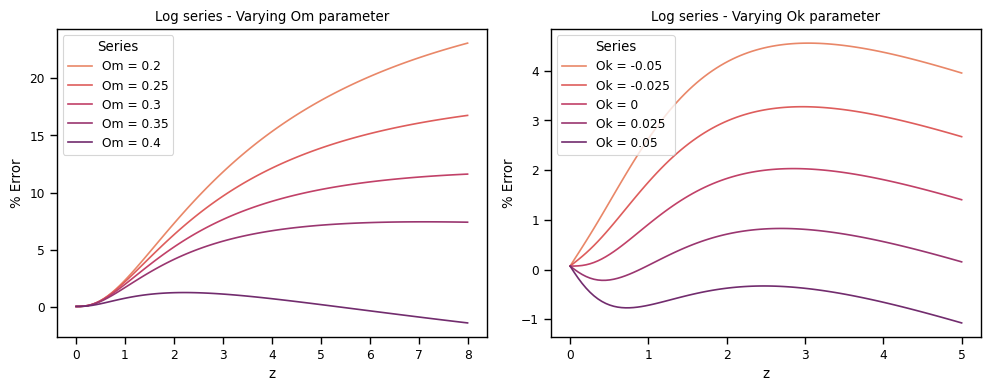

In [133]:
err_log = []
Om = [0.2, 0.25, 0.3, 0.35, 0.5]
n = len(Om)
orderr = 4
for i in tqdm(range(n)):

    H0_true = 73
    Om_true = Om[i]
    Ok_true = 0
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 8, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(dLpade21(zs, H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= orderr) - dls_true)/dls_true)


# Prepare the data in long form
data_Om = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Om = 0.2'] * len(zs) + ['Om = 0.25'] * len(zs) + ['Om = 0.3'] * len(zs) + ['Om = 0.35'] * len(zs)
     + ['Om = 0.4'] * len(zs)
})

err_log = []
Ok = [-0.05, -0.025, 0, 0.025, 0.05]
n = len(Om)

for i in tqdm(range(n)):

    H0_true = 73
    Om_true = 0.3 #Om[i]
    Ok_true = Ok[i]
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(dLpadeaverage(zs, H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= orderr) - dls_true)/dls_true)

# Prepare the data in long form
data_Ok = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Ok = -0.05'] * len(zs) + ['Ok = -0.025'] * len(zs) + ['Ok = 0'] * len(zs) + ['Ok = 0.025'] * len(zs)
     + ['Ok = 0.05'] * len(zs)
})

# Create a figure with two subplots side by side (ncols=2)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Om, palette='flare', ax = axes[0])
axes[0].set_xlabel('z')
axes[0].set_ylabel('% Error')
axes[0].set_title('Log series - Varying Om parameter')

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Ok, palette='flare', ax = axes[1])
axes[1].set_xlabel('z')
axes[1].set_ylabel('% Error')
axes[1].set_title('Log series - Varying Ok parameter')

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 598.08it/s]


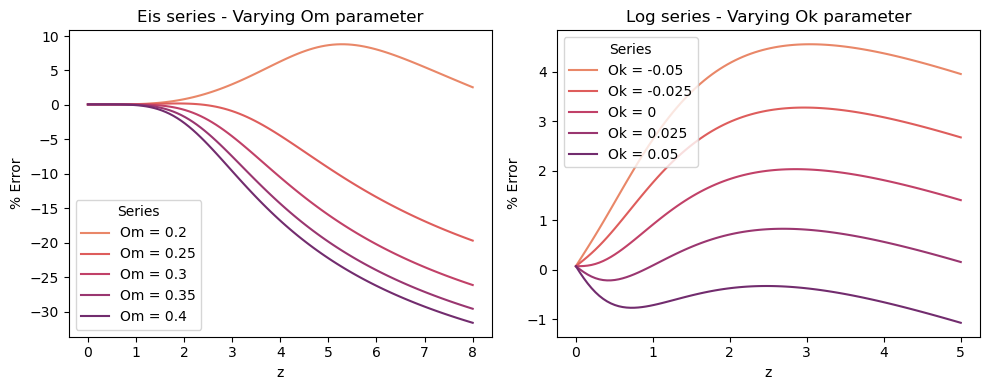

In [21]:
# EIS

err_eis = []
Om = [0.2, 0.25, 0.3, 0.35, 0.4]
n = len(Om)
orderr = 5
for i in tqdm(range(n)):

    H0_true = 73
    Om_true = Om[i]
    Ok_true = 0
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)
    E1, E2, E3, E4, E5 = to_statefinders(q0_true, j0p = j0_true, s0p = s0_true, c0p = c0_true, p0p = p0_true, order=5)

    zs = np.linspace(0.001, 8, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_eis.append(100*(EIS(zs, H0_true,E1, E2 = E2, E3 = E3, E4 = E4, E5 = E5 ,order= 5) - dls_true)/dls_true)


# Prepare the data in long form
data_Om_eis = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_eis[0]) + list(err_eis[1]) + list(err_eis[2]) + list(err_eis[3]) + list(err_eis[4]),
    'Series': ['Om = 0.2'] * len(zs) + ['Om = 0.25'] * len(zs) + ['Om = 0.3'] * len(zs) + ['Om = 0.35'] * len(zs)
     + ['Om = 0.4'] * len(zs)
})

err_log = []
Ok = [-0.05, -0.025, 0, 0.025, 0.05]
n = len(Om)

for i in tqdm(range(n)):

    H0_true = 73
    Om_true = 0.3 #Om[i]
    Ok_true = Ok[i]
    w_true = -1
    H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)

    zs = np.linspace(0.001, 5, 100)
    my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    err_log.append(100*(dLpadeaverage(zs, H0_true, q0_true, j0_true, s0_true, c0_true,p0_true,order= orderr) - dls_true)/dls_true)

# Prepare the data in long form
data_Ok = pd.DataFrame({
    'zs': list(zs) * 5,
    'Difference': list(err_log[0]) + list(err_log[1]) + list(err_log[2]) + list(err_log[3]) + list(err_log[4]),
    'Series': ['Ok = -0.05'] * len(zs) + ['Ok = -0.025'] * len(zs) + ['Ok = 0'] * len(zs) + ['Ok = 0.025'] * len(zs)
     + ['Ok = 0.05'] * len(zs)
})

# Create a figure with two subplots side by side (ncols=2)
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Om_eis, palette='flare', ax = axes[0])
axes[0].set_xlabel('z')
axes[0].set_ylabel('% Error')
axes[0].set_title('Eis series - Varying Om parameter')

# Plot with hue and palette
sns.lineplot(x='zs', y='Difference', hue='Series',  data=data_Ok, palette='flare', ax = axes[1])
axes[1].set_xlabel('z')
axes[1].set_ylabel('% Error')
axes[1].set_title('Log series - Varying Ok parameter')

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

<font size="5">% error evolution with z for a fixed cosmology

  0%|                                                   | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_13406/4060394510.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_eistrue[k,i] = 100*(abs(my_eis - dls_true) / dls_true)
100%|█████████████████████████████████████████| 100/100 [00:05<00:00, 18.78it/s]


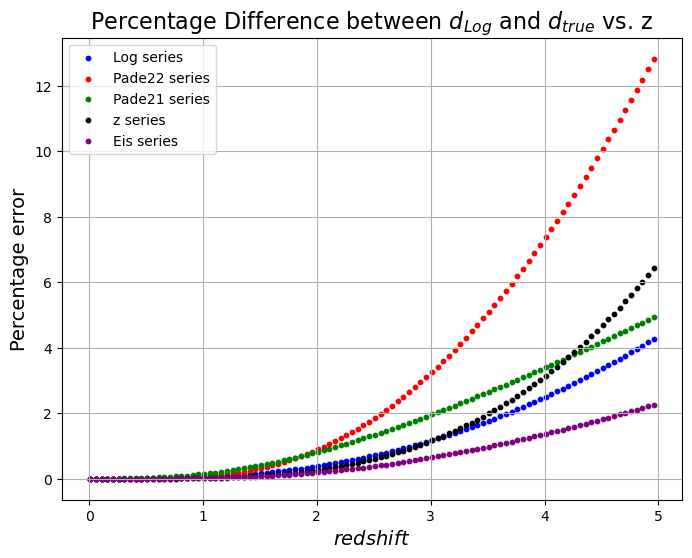

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(20)

n = 100
zmin = 0.001
zmax = 1.5

dtheta_log = np.zeros((n, 4))
diff_logtrue = np.zeros((n, n))
diff_pade22true = np.zeros((n, n))
diff_pade21true = np.zeros((n, n))
diff_ztrue = np.zeros((n, n))
diff_eistrue = np.zeros((n, n))

av_diff_log = np.zeros(n)
av_diff_pade22 = np.zeros(n)
av_diff_pade21 = np.zeros(n)
av_diff_z = np.zeros(n)
av_diff_eis = np.zeros(n)

zs_rec = np.zeros(n)

# n=100 iterations estimating the values for the distances
for k in tqdm(range(n)):
    
    zs_temp = 0.01 + k * 0.05
    zs_rec[k] = zs_temp
    log1zs_temp = np.log(1 + zs_temp)
    
    for i in range(n):
        #cosmology parameters
        H0_true = np.random.uniform(73, 75)
        Om_true = np.random.uniform(0.3, 0.36)
        Ok_true = 0
        w_true = -1
        H0_true, q0_true, j0_true, s0_true, c0_true, p0_true = to_cosmographic(H0_true, Om_true, Ok_true, w_true)
        
        my_cosmo = cosmo.wCDM(H0=H0_true, Om0=Om_true, Ode0=1.0-Om_true, w0=w_true)
        dls_true = my_cosmo.luminosity_distance(zs_temp).to(u.Mpc).value
        my_log = log_series(log1zs_temp, H0_true, q0_true, j0_true, s0_true)
        my_Pade22 = dLpade22(zs_temp, H0_true, q0_true, j0_true, s0_true)
        my_Pade21 = dLpade21(zs_temp, H0_true, q0_true, j0_true)
        my_z = z_series(zs_temp, H0_true, q0_true, j0_true, s0_true)
    
        # Eis series
        E0_true = 1
        E1_true = 1+ q0_true
        E2_true = -q0_true**2 + j0_true
        E3_true = 3*q0_true**2 + 3*q0_true**3 - j0_true*(4*q0_true + 3)-s0_true
        zs_eis = np.array([zs_temp])
        
        my_eis = dL_EIS41(zs_eis, E0=E0_true, E1=E1_true, E2=E2_true, E3 = E3_true, H0=H0_true)
        
        diff_logtrue[k,i] = 100 * (abs(my_log - dls_true) / dls_true)
        diff_pade22true[k,i] = 100*(abs(my_Pade22 - dls_true) / dls_true)
        diff_pade21true[k,i] = 100*(abs(my_Pade21 - dls_true) / dls_true)
        diff_ztrue[k,i] = 100*(abs(my_z - dls_true) / dls_true)
        diff_eistrue[k,i] = 100*(abs(my_eis - dls_true) / dls_true)
        
    av_diff_log[k] = np.mean(diff_logtrue)
    av_diff_pade22[k] = np.mean(diff_pade22true)
    av_diff_pade21[k] = np.mean(diff_pade21true)
    av_diff_z[k] = np.mean(diff_ztrue)
    av_diff_eis[k] = np.mean(diff_eistrue)


# Plot av_difflog vs z
plt.figure(figsize=(8, 6))
plt.scatter(zs_rec, av_diff_log, color='blue', alpha=1, label='Log series', s=10)
plt.scatter(zs_rec, av_diff_pade22, color='red', alpha=1, label='Pade22 series', s=10)
plt.scatter(zs_rec, av_diff_pade21, color='green', alpha=1, label='Pade21 series', s=10)
plt.scatter(zs_rec, av_diff_z/10, color='black', alpha=1, label='z series', s=10)
plt.scatter(zs_rec, av_diff_eis, color='purple', alpha=1, label='Eis series', s=10)
plt.legend()
plt.xlabel('$redshift$', fontsize=14)
plt.ylabel('Percentage error', fontsize=14)
plt.title('Percentage Difference between $d_{Log}$ and $d_{true}$ vs. z', fontsize=16)
plt.grid(True)
plt.show()